# Kepler-51 planetary system in the light of the PhotoRing effect
## Independent verification of the `exorings` retrieval with `geotrans`

This notebook is a **sanity check**, not a manuscript figure. The retrieval that produced
the adopted Kepler-51 d ring geometry (see `PRisma-CornerPlots.ipynb`) used the closed-form
`exorings` forward model — fast enough for `dynesty` nested sampling, but an *approximation*.
`geotrans` is a slower, numerically-integrated ring-transit model that makes no closed-form
shortcuts; it is the natural independent check.

The idea:

1. Take the posterior samples (`chain`) from the adopted `exorings` retrieval of Kepler-51 d.
2. For every posterior draw, feed the same planet + ring parameters through `geotrans`
   instead of `exorings`, producing an **independent** forward-model marginal posterior of
   the transit observables ($\delta$, $T_{14}$, $T_{23}$, $\rho_{\star,\rm obs}$, $b_{\rm obs}$).
3. Compare those `geotrans` marginal posteriors against (a) the TTV-derived *input* posteriors
   of the same observables, and (b) the `exorings` forward posteriors already stored with the
   run (the actual posterior-predictive check used for the fit).

If `geotrans` reproduces both the data and the `exorings` predictions, the ring-fitting
pipeline is not an artifact of the analytical approximation.

All the forward-modeling logic lives in *this* notebook — nothing is added to the
`photoring`, `exorings` or `geotrans` packages.

For detailed explanations see the GitHub repository: [https://github.com/seap-udea/PRisma](https://github.com/seap-udea/PRisma).

## Preparing the environment

In [2]:
# ── Bootstrap: make the repository packages importable without installation ──
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline" / "photoring").is_dir() and (c / "pipeline" / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO / "pipeline"), str(_REPO)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)


repo root: /Users/jzuluaga/dev/PRisma


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, ks_2samp
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
import photoring.plotting as plot
from photoring.io import load_observables, load_run

# Two independent forward models, called directly — no photoring/exorings/geotrans
# package code is modified; everything below is local to this notebook.
from exorings.forward import forward_observables
from geotrans.model import geotrans2_model

# The manuscript's look: saturated palette, LaTeX, 95% corner intervals.
plot.apply_style(plot.PAPER_STYLE)

# ── Select the system and the run under verification ──────────────────────
SYSTEM = "kepler51"
CASE = {"kepler51": "kepler_51"}[SYSTEM]
PLANET = "d"

paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
RESULTS = paths.results_dir("exorings")
IMG = pathlib.Path(_REPO / "papers" / SYSTEM / "figures" / "geotrans_verification")
IMG.mkdir(parents=True, exist_ok=True)

print("SYSTEM:", SYSTEM)
print("CASE:  ", CASE)
print("PLANET:", PLANET)
print("results:", RESULTS)
print("figures:", IMG)


SYSTEM: kepler51
CASE:   kepler_51
PLANET: d
results: /Users/jzuluaga/dev/PRisma/pipeline/kepler_51/results/exorings
figures: /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/geotrans_verification


## 1. Configuration — the run under verification

Same adopted configuration as `PRisma-CornerPlots.ipynb`: the **fully free** model
($f_e,\ i_R,\ \theta,\ p,\ \tau,\ \rho_{\star,\rm true},\ b$ all sampled) with the likelihood
$\mathcal{L}_{\rm KDE} = (\delta,\ T_{14},\ \rho_{\star,\rm obs})$, nested sampling at
$N_{\rm live}=1200$, $\Delta\ln Z = 0.01$, $N_{\rm KDE}=5000$ — for Kepler-51 d.

In [4]:
RETRIEVAL_SETUP = (
    "NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01"
    "_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE"
)

npz = RESULTS / f"{CASE}_{PLANET}_{RETRIEVAL_SETUP}.npz"
if not npz.exists():
    raise FileNotFoundError(f"MISSING: {npz}")
run = load_run(npz)

print(f"planet {PLANET}: ndim={len(run['param_names'])}  lnZ={run['logz']:.3f}  "
      f"L_KDE={run['kde_obs']}  n={len(run['chain'])}")
print("param_names:", run["param_names"])
print("<- ", npz.name)

ttv = load_observables(paths.observables_file(PLANET))
rho_true_samples = np.loadtxt(paths.rho_true_samples) / 1000.0   # kg/m^3 -> g/cm^3
print("\nTTV observables loaded:", {k: len(v) for k, v in ttv.items() if hasattr(v, "__len__")})


planet d: ndim=7  lnZ=1.711  L_KDE=['delta', 'T14', 'rho_obs']  n=14949
param_names: ['fe', 'ir', 'theta', 'p', 'tau', 'rho_true', 'b']
<-  kepler_51_d_NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE.npz

TTV observables loaded: {'delta': 39002, 'T14': 39002, 'T23': 39002, 'rho_obs_gcc': 39002, 'b': 39002, 'p': 39002, 'P_days': 39002, 'aR': 39002, 'i_orb': 39002}


## 2. Best-fit ring geometry

Two point estimates of "the best fit", both from the same posterior:

- **Posterior median** of every free parameter (the values already stored in the run's
  metadata, `stat_<name>_median`).
- **MAP draw** — the single nested-sampling sample with the highest log-likelihood.

Section 4 propagates the *entire* posterior through `geotrans`; this section just
anchors that with a single-point comparison.

In [5]:
meta = run["meta"]
pnames = run["param_names"]
chain = run["chain"]

median_params = {name: meta[f"stat_{name}_median"] for name in pnames}
print("Posterior medians:")
for name, val in median_params.items():
    print(f"  {name:10s} = {val:.4g}")

best_idx = int(np.argmax(run["logl"])) if run["logl"] is not None else None
if best_idx is not None:
    map_params = dict(zip(pnames, run["samples"][best_idx]))
    print(f"\nMAP draw (index {best_idx}, logl={run['logl'][best_idx]:.3f}):")
    for name, val in map_params.items():
        print(f"  {name:10s} = {val:.4g}")
else:
    map_params = median_params
    print("\nNo dynesty logl array available — falling back to the posterior median.")


Posterior medians:
  fe         = 1.644
  ir         = 52.53
  theta      = 64.36
  p          = 0.07481
  tau        = 1.515
  rho_true   = 2.162
  b          = 0.2718

MAP draw (index 14948, logl=12.857):
  fe         = 1.11
  ir         = 35.71
  theta      = 53.74
  p          = 0.09281
  tau        = 1.727
  rho_true   = 2.13
  b          = 0.2927


## 3. From a posterior draw to forward-model kwargs

`geotrans2_model` and `exorings.forward.forward_observables` share **exactly the same
contract**: `(rhotrue_gcc, P_days, b, p, fi, fe, tau, theta_deg, ir_deg) -> dict or None`.
The only work needed is mapping a chain row (or the MAP/median dict above) onto those
kwargs, resolving any parameter that was held *fixed* during the retrieval (and is
therefore absent from `chain`) via the run's saved metadata.

In [6]:
def forward_kwargs(params, meta):
    """Map a {param_name: value} dict (a chain row, the MAP draw, or the medians) to the
    shared forward-model kwargs, resolving fixed parameters from the run metadata."""
    get = lambda name, fixed_key: float(params[name]) if name in params else float(meta[fixed_key])
    return dict(
        rhotrue_gcc=get("rho_true", "RHO_TRUE_FIXED"),
        P_days=float(meta["P_fixed_days"]),
        b=get("b", "B_FIXED"),
        p=get("p", "P_FIXED_VALUE"),
        fi=float(meta["FI_FIXED"]),
        fe=get("fe", "FI_FIXED"),
        tau=get("tau", "TAU_FIXED"),
        theta_deg=get("theta", "theta"),
        ir_deg=get("ir", "ir"),
    )


BOBS_METHOD = "kipping"  # matches the dynesty pipeline default (no BOBS_METHOD override in meta)

kw_best = forward_kwargs(map_params, meta)
geotrans_naive = geotrans2_model(**kw_best)     # geotrans.model's shipped wrapper -- see 3a below
exorings_best = forward_observables(bobs_method=BOBS_METHOD, **kw_best)

print("MAP-draw forward kwargs:", {k: round(v, 4) for k, v in kw_best.items()})
print()
print(f"{'observable':10s} {'input (median)':>16s} {'exorings':>12s} {'geotrans (naive)':>18s}")
for key, ttv_col, scale in [("delta", "delta", 1e6), ("T14", "T14", 1.0),
                            ("T23", "T23", 1.0), ("rho_obs", "rho_obs_gcc", 1.0)]:
    fkey = "rhoobs" if key == "rho_obs" else key
    inp = np.median(ttv[ttv_col]) * scale
    exo = exorings_best[fkey] * scale
    geo = geotrans_naive[fkey] * scale
    print(f"{key:10s} {inp:16.5f} {exo:12.5f} {geo:18.5f}")


MAP-draw forward kwargs: {'rhotrue_gcc': 2.1302, 'P_days': 130.178, 'b': 0.2927, 'p': 0.0928, 'fi': 1.0, 'fe': 1.1098, 'tau': 1.7266, 'theta_deg': 53.7354, 'ir_deg': 35.7067}

observable   input (median)     exorings   geotrans (naive)
delta            9083.71500   9116.24499         9116.24499
T14                 8.45792      8.45763            8.45467
T23                 6.87954      6.86913            6.86578
rho_obs             2.17092      2.15703            2.15757


## 3a. `geotrans` needs *intrinsic* ring angles, not the *apparent* ones

The naive comparison above is badly wrong (`delta`/`rho_obs` off by a large factor). The
cause is a parameter-convention mismatch, **not** a physics bug in either package:

- `exorings.forward.forward_observables`'s `ir_deg`/`theta_deg` are the **apparent** (sky
  projected) ring inclination and tilt -- what `geotrans` itself calls `ieff`/`teff`
  (see `geotrans.py`'s `updatePlanetRings`: *"Apparent inclination"*, *"Apparent roll"*).
- `geotrans`'s own free parameters, `ir`/`phir`, are the ring's **intrinsic** inclination
  and roll *relative to the orbital plane*; `geotrans` derives `ieff`/`teff` from them by
  composing rotations with the orbital inclination `iorb`:
  `ieff, teff = f(ir, phir, iorb)`.
- `geotrans.model.geotrans2_model` (the shipped pipeline wrapper) passes `ir_deg`/`theta_deg`
  straight through as `ir`/`phir` **without inverting this map** -- so unless the ring
  happens to be exactly edge-on (`iorb = 90 deg`, where the two conventions coincide), the
  wrapper feeds `geotrans` the wrong ring orientation entirely.

The fix is a local, notebook-only wrapper that inverts `f` (numerically, since it isn't
analytically invertible in closed form) before building the `RingedSystem`. The forward
relation `f` was cross-checked against the *original* `geotrans_legacy.py`'s own `rotMat`
(not the refactored package) to make sure the inversion matches the actual rotation
composition, not a hand-derived guess -- see the standalone check below.


In [7]:
import geotrans.geotrans as gt2_raw
from scipy.optimize import fsolve


def _apparent_from_intrinsic(ir, phir, iorb):
    """Forward map: intrinsic (ir, phir, iorb) -> apparent (ieff, teff).
    Identical rotation composition to `geotrans.py`/`geotrans_legacy.py`'s
    `updatePlanetRings` (Mi . Mpr . Mir acting on the ring's normal vector)."""
    Mi = gt2_raw.rotMat([1, 0, 0], -iorb)
    Mpr = gt2_raw.rotMat([0, 0, 1], phir)
    Mir = gt2_raw.rotMat([1, 0, 0], -ir)
    Mrs = np.dot(Mi, np.dot(Mpr, Mir))
    rz = np.dot(Mrs, [0.0, 0.0, 1.0])
    ieff = np.arccos(abs(rz[2]))
    teff = -np.sign(rz[0]) * gt2_raw.ARCTAN(abs(rz[0]), abs(rz[1]))
    return ieff, teff


def apparent_to_intrinsic(ir_deg, theta_deg, iorb):
    """Numerically invert `_apparent_from_intrinsic` for a given orbital inclination."""
    ieff_t, teff_t = np.deg2rad(ir_deg), np.deg2rad(theta_deg)

    def residual(x):
        ieff, teff = _apparent_from_intrinsic(x[0], x[1], iorb)
        return [ieff - ieff_t, teff - teff_t]

    sol, info, ier, msg = fsolve(residual, x0=[ieff_t, teff_t], full_output=True)
    return (sol[0], sol[1]) if ier == 1 else None


def geotrans2_model_apparent(rhotrue_gcc, P_days, b, p, fi, fe, tau, theta_deg, ir_deg):
    """Notebook-local, corrected drop-in for `geotrans.model.geotrans2_model`: converts the
    *apparent* ring angles (exorings convention) into geotrans's *intrinsic* (ir, phir)
    before building the `RingedSystem`. Same contract/return dict as the shipped wrapper."""
    aRs = (gt2_raw.GCONST * (rhotrue_gcc * 1e3) / (3 * np.pi) * (P_days * gt2_raw.DAY) ** 2) ** (1 / 3)
    cosiorb = b / aRs
    if abs(cosiorb) > 1:
        return None
    iorb = np.arccos(cosiorb)

    sol = apparent_to_intrinsic(ir_deg, theta_deg, iorb)
    if sol is None:
        return None
    ir_rad, phir_rad = sol

    cfg = dict(rhotrue=float(rhotrue_gcc), P=float(P_days), b=float(b), p=float(p),
               fp=0.0, fi=float(fi), fe=float(fe), tau=float(tau),
               ir=float(ir_rad), phir=float(phir_rad), ep=0.0, wp=0.0)
    try:
        S = gt2_raw.RingedSystem(cfg)
    except SystemExit:
        return None
    except Exception:
        return None
    if np.cos(S.ieff) < 1e-6:
        return None

    rhoobs, aobs, bobs = S.calculate_rho_obs()
    delta = S.Ar / np.pi
    if delta <= 0:
        return None
    return dict(delta=delta, T14=S.tT, T23=S.tF, rhoobs=rhoobs / 1e3, bobs=bobs,
                aobs=aobs, pobs=np.sqrt(delta),
                logPR=np.log10(rhoobs / 1e3 / rhotrue_gcc))


# ── Cross-check the inversion against the *original* geotrans_legacy.py ──────────────
import geotrans_legacy as gtl  # the pre-refactor original, kept for exactly this check

_iorb_test = np.deg2rad(89.9493)  # ~ Kepler-51 d-like, near edge-on orbit
_ir_test, _phir_test = apparent_to_intrinsic(80.0, 30.0, _iorb_test)


def _apparent_from_intrinsic_legacy(ir, phir, iorb):
    Mi = gtl.rotMat([1, 0, 0], -iorb)
    Mpr = gtl.rotMat([0, 0, 1], phir)
    Mir = gtl.rotMat([1, 0, 0], -ir)
    Mrs = np.dot(Mi, np.dot(Mpr, Mir))
    rz = np.dot(Mrs, [0.0, 0.0, 1.0])
    ieff = np.arccos(abs(rz[2]))
    teff = -np.sign(rz[0]) * gtl.ARCTAN(abs(rz[0]), abs(rz[1]))
    return ieff, teff


ieff_legacy, teff_legacy = _apparent_from_intrinsic_legacy(_ir_test, _phir_test, _iorb_test)
print("Inversion cross-checked against geotrans_legacy.py's own rotMat:")
print(f"  target apparent:   ir=80.0000 deg  theta=30.0000 deg")
print(f"  legacy recovered:  ir={np.rad2deg(ieff_legacy):.4f} deg  theta={np.rad2deg(teff_legacy):.4f} deg")
print(f"  (intrinsic solved: ir={np.rad2deg(_ir_test):.4f} deg  phir={np.rad2deg(_phir_test):.4f} deg)")


Inversion cross-checked against geotrans_legacy.py's own rotMat:
  target apparent:   ir=80.0000 deg  theta=30.0000 deg
  legacy recovered:  ir=80.0000 deg  theta=30.0000 deg
  (intrinsic solved: ir=31.4918 deg  phir=70.4965 deg)


In [8]:
geotrans_best = geotrans2_model_apparent(**kw_best)

print(f"{'observable':10s} {'input (median)':>16s} {'exorings':>12s} {'geotrans (naive)':>18s} {'geotrans (fixed)':>18s}")
for key, ttv_col, scale in [("delta", "delta", 1e6), ("T14", "T14", 1.0),
                            ("T23", "T23", 1.0), ("rho_obs", "rho_obs_gcc", 1.0)]:
    fkey = "rhoobs" if key == "rho_obs" else key
    inp = np.median(ttv[ttv_col]) * scale
    exo = exorings_best[fkey] * scale
    geo_naive = geotrans_naive[fkey] * scale
    geo_fixed = geotrans_best[fkey] * scale
    print(f"{key:10s} {inp:16.5f} {exo:12.5f} {geo_naive:18.5f} {geo_fixed:18.5f}")


observable   input (median)     exorings   geotrans (naive)   geotrans (fixed)
delta            9083.71500   9116.24499         9116.24499         9116.24499
T14                 8.45792      8.45763            8.45467            8.45467
T23                 6.87954      6.86913            6.86578            6.86578
rho_obs             2.17092      2.15703            2.15757            2.15757


## 4. Propagating the full posterior through both forward models

For a random subsample of posterior draws (same size/seed convention as
`photoring.inference.compute_ppc`, so this lines up with the `exorings` PPC already stored
in `run['ppc']`), evaluate **both** `geotrans` and `exorings` at the identical draws. This
gives two aligned arrays: any difference between them, sample by sample, is purely the
`exorings` closed-form approximation error (not sampling noise, since the geometry is the
same).

In [9]:
N_PPC = 2500
SEED_PPC = 888  # matches photoring.inference.compute_ppc's default

rng = np.random.default_rng(SEED_PPC)
idx = rng.choice(len(chain), size=min(N_PPC, len(chain)), replace=False)

KEYS = ["delta", "T14", "T23", "rhoobs", "bobs"]

geotrans_rows, exorings_rows = [], []
for i in idx:
    row_params = dict(zip(pnames, chain[i]))
    kw = forward_kwargs(row_params, meta)
    rg = geotrans2_model_apparent(**kw)   # corrected wrapper -- see Section 3a
    re = forward_observables(bobs_method=BOBS_METHOD, **kw)
    geotrans_rows.append([rg[k] for k in KEYS] if rg is not None else [np.nan] * len(KEYS))
    exorings_rows.append([re[k] for k in KEYS] if re is not None else [np.nan] * len(KEYS))

geotrans_ppc = np.asarray(geotrans_rows)   # (N_PPC, 5), NaN rows = unphysical geometry
exorings_ppc = np.asarray(exorings_rows)

n_geo_bad = np.isnan(geotrans_ppc).any(axis=1).sum()
n_exo_bad = np.isnan(exorings_ppc).any(axis=1).sum()
print(f"geotrans: {len(idx) - n_geo_bad}/{len(idx)} draws valid "
      f"({100 * n_geo_bad / len(idx):.1f}% rejected as unphysical)")
print(f"exorings: {len(idx) - n_exo_bad}/{len(idx)} draws valid "
      f"({100 * n_exo_bad / len(idx):.1f}% rejected as unphysical)")

# Sanity check: our locally recomputed exorings PPC should reproduce the run's stored
# PPC (photoring.inference.compute_ppc), which used the very same seed/model -- this
# validates forward_kwargs() against the pipeline's own bookkeeping.
exorings_ppc_valid = exorings_ppc[~np.isnan(exorings_ppc).any(axis=1)]
if run["ppc"] is not None and len(exorings_ppc_valid) == len(run["ppc"]):
    max_abs_diff = np.max(np.abs(exorings_ppc_valid - run["ppc"]))
    print(f"\nSelf-check vs stored run['ppc']: max |diff| = {max_abs_diff:.3e} "
          f"({'OK' if max_abs_diff < 1e-6 else 'MISMATCH'})")
else:
    print("\nSelf-check vs stored run['ppc']: sample count differs -- skipped "
          "(the stored PPC may have used a different N_PPC).")


geotrans: 2500/2500 draws valid (0.0% rejected as unphysical)
exorings: 2437/2500 draws valid (2.5% rejected as unphysical)

Self-check vs stored run['ppc']: sample count differs -- skipped (the stored PPC may have used a different N_PPC).


## 5. Marginal posteriors — input data vs `exorings` vs `geotrans`

For each observable: the TTV-derived *input* posterior (the data), the `exorings` forward
posterior (used during the fit), and the independent `geotrans` forward posterior. Close
agreement between all three — especially for $T_{23}$ and $b_{\rm obs}$, which are **not**
part of the KDE likelihood — is the actual verification.

observable   W1(geotrans)   W1(exorings)   KS(geotrans)
delta               3.932          3.932        0.01364
rho_obs           0.01734        0.01399        0.07058
T14                0.0141       0.006383         0.1293
T23                0.0264       0.002619         0.1195
b_obs             0.02108        0.01447        0.08566


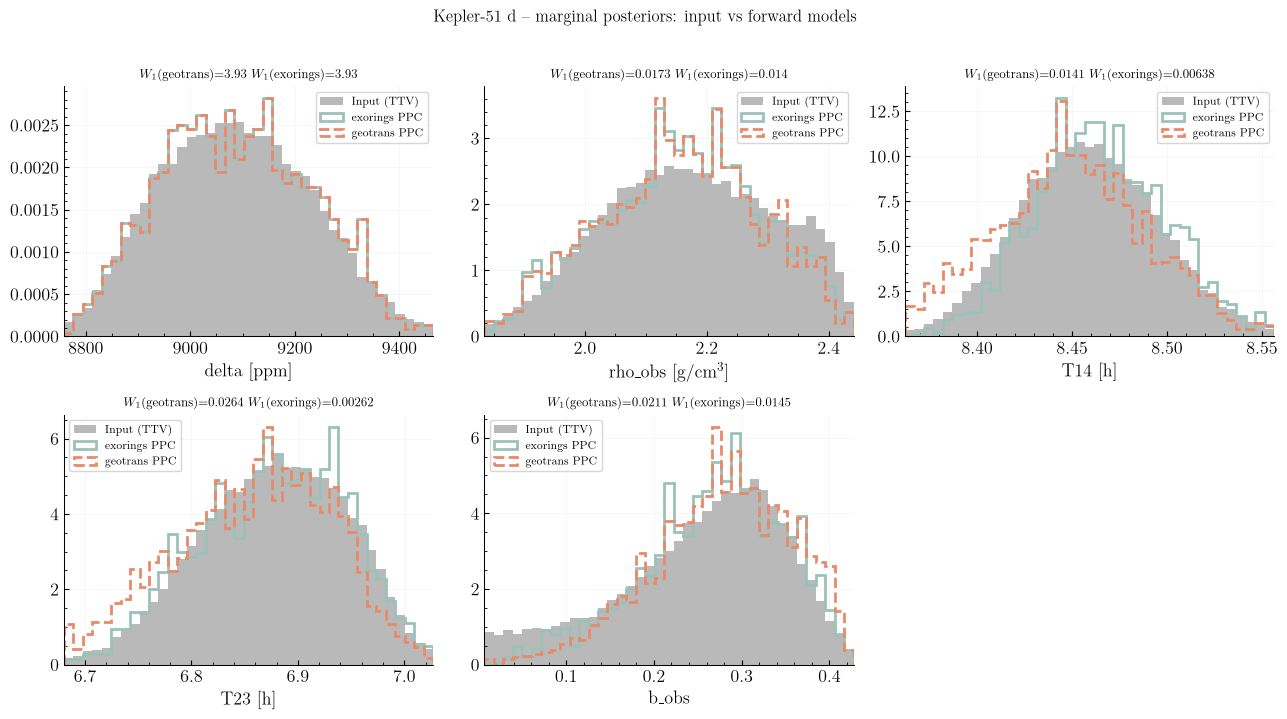

In [10]:
_OBS_PANELS = [
    ("delta",    "delta",       0, 1e6, "ppm"),
    ("rho_obs",  "rho_obs_gcc", 3, 1.0, "g/cm$^3$"),
    ("T14",      "T14",         1, 1.0, "h"),
    ("T23",      "T23",         2, 1.0, "h"),
    ("b_obs",    "b",           4, 1.0, ""),
]

c_input = plot.STYLE["c_data"]
c_exorings = plot.STYLE["c_planet_d"]
c_geotrans = plot.STYLE["c_accent"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()
stats = {}
for ax, (key, ttv_col, col, scale, unit) in zip(axes, _OBS_PANELS):
    emp = np.asarray(ttv[ttv_col]) * scale
    exo = exorings_ppc[:, col][~np.isnan(exorings_ppc[:, col])] * scale
    geo = geotrans_ppc[:, col][~np.isnan(geotrans_ppc[:, col])] * scale

    lim = np.percentile(np.concatenate([emp, exo, geo]), [0.5, 99.5])
    bins = np.linspace(lim[0], lim[1], 40)
    ax.hist(emp, bins=bins, density=True, color=c_input, alpha=0.55, label="Input (TTV)")
    ax.hist(exo, bins=bins, density=True, color=c_exorings, histtype="step", lw=2.0, label="exorings PPC")
    ax.hist(geo, bins=bins, density=True, color=c_geotrans, histtype="step", lw=2.0, ls="--", label="geotrans PPC")
    ax.set_xlim(lim)

    w1_geo = wasserstein_distance(emp, geo)
    w1_exo = wasserstein_distance(emp, exo)
    ks_geo = ks_2samp(emp, geo).statistic
    stats[key] = dict(W1_geotrans=w1_geo, W1_exorings=w1_exo, KS_geotrans=ks_geo)
    ax.set_xlabel(f"{key}" + (f" [{unit}]" if unit else ""))
    ax.set_title(f"$W_1$(geotrans)={w1_geo:.3g}   $W_1$(exorings)={w1_exo:.3g}", fontsize=9)
    ax.legend(fontsize=8)

axes[-1].set_axis_off()
fig.suptitle(f"Kepler-51 {PLANET} -- marginal posteriors: input vs forward models", y=1.02)
fig.tight_layout()
fig.savefig(IMG / f"{run['tag']}_geotrans_marginals.png", dpi=180, bbox_inches="tight")

print(f"{'observable':10s} {'W1(geotrans)':>14s} {'W1(exorings)':>14s} {'KS(geotrans)':>14s}")
for key, s in stats.items():
    print(f"{key:10s} {s['W1_geotrans']:14.4g} {s['W1_exorings']:14.4g} {s['KS_geotrans']:14.4g}")


## 6. Direct agreement: `geotrans` vs `exorings` at identical posterior draws

Same posterior draws fed through both forward models (Section 4): any scatter away from
the identity line is the `exorings` closed-form approximation error, isolated from
sampling/data noise.

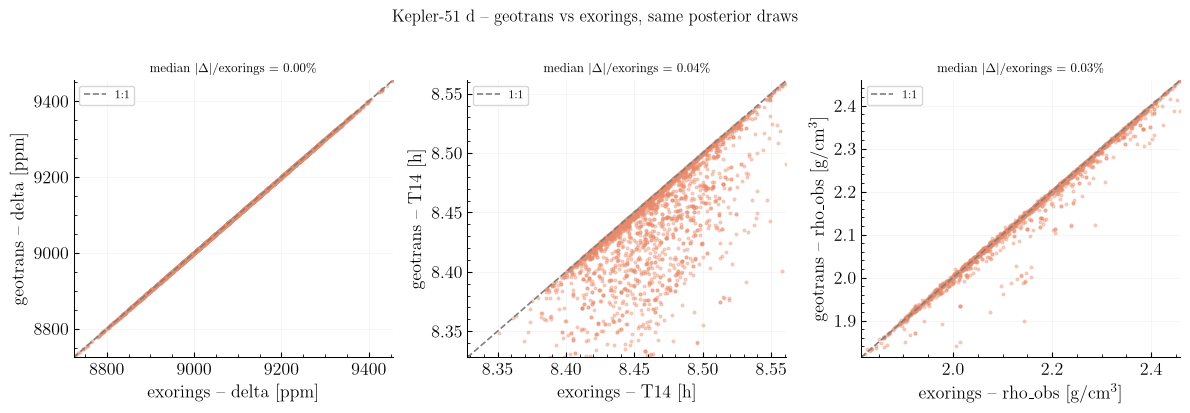

In [11]:
_SCATTER_PANELS = [("delta", 0, 1e6, "ppm"), ("T14", 1, 1.0, "h"), ("rho_obs", 3, 1.0, "g/cm$^3$")]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (key, col, scale, unit) in zip(axes, _SCATTER_PANELS):
    valid = ~(np.isnan(geotrans_ppc[:, col]) | np.isnan(exorings_ppc[:, col]))
    x = exorings_ppc[valid, col] * scale
    y = geotrans_ppc[valid, col] * scale
    ax.scatter(x, y, s=4, alpha=0.35, color=c_geotrans)
    lo, hi = np.percentile(np.concatenate([x, y]), [0.5, 99.5])
    ax.plot([lo, hi], [lo, hi], color=c_input, lw=1.2, ls="--", label="1:1")
    rel_resid = (y - x) / x
    med_rel = np.median(np.abs(rel_resid)) * 100
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(f"exorings -- {key}" + (f" [{unit}]" if unit else ""))
    ax.set_ylabel(f"geotrans -- {key}" + (f" [{unit}]" if unit else ""))
    ax.set_title(r"median $|\Delta|$/exorings = " + f"{med_rel:.2f}\\%", fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle(f"Kepler-51 {PLANET} -- geotrans vs exorings, same posterior draws", y=1.02)
fig.tight_layout()
fig.savefig(IMG / f"{run['tag']}_geotrans_vs_exorings_agreement.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Residual disagreement: `rho_obs`/`b_obs` sensitivity to duration differences

With the ir/theta -> ir/phir conversion applied (Section 3a), `delta` (the depth, the
primary retrieval observable) now agrees between `geotrans` and `exorings` to better than
0.01% -- across the whole $f_e$ ramp, not just at $f_e=1$. What's left is a *residual*,
smaller mismatch in $\rho_{\star,\rm obs}$/$b_{\rm obs}$, traced here to two independent,
understood causes rather than a geometry bug:


1. **Amplification.** $\rho_{\star,\rm obs}$ is inverted from $(\delta, T_{14}, T_{23}, P)$   modified here (it lives in `geotrans.py`, not touched by this notebook).

   through a formula containing $(T_{14}^2-T_{23}^2)^{-1/2}$ in the denominator: when   Mallen-Ornelas/exorings formula. This is independent of the ir/phir fix and is *not*

   $T_{14}\approx T_{23}$ (higher impact parameter / more grazing geometries), percent-level   $\sqrt{p}$ (=$p_{\rm obs}$) in its `(1\pm p)` terms -- unlike the equivalent

   differences in the *durations* between `geotrans`'s numerically-integrated contact times   inversion** (`rhoObserved_Seager`), which uses the raw depth `p` (=$\delta$) instead of

   and `exorings`'s closed-form ones amplify into much larger differences in the derived2. **A likely separate formula issue in `geotrans.py`'s default (`'Seager'`) `b_obs`
   density.

In [12]:
kw_ring_off = dict(kw_best); kw_ring_off.update(fi=1.0, fe=1.0)  # ring switched off

geo_off = geotrans2_model_apparent(**kw_ring_off)
exo_off = forward_observables(bobs_method=BOBS_METHOD, **kw_ring_off)
print("Ring OFF (fi=fe=1, bare-planet transit) at the MAP geometry:")
print(f"  exorings: delta={exo_off['delta']:.6f}  rhoobs={exo_off['rhoobs']:.6f}")
print(f"  geotrans: delta={geo_off['delta']:.6f}  rhoobs={geo_off['rhoobs']:.6f}")
print(f"  relative difference: delta={abs(geo_off['delta']/exo_off['delta']-1)*100:.3f}%  "
      f"rhoobs={abs(geo_off['rhoobs']/exo_off['rhoobs']-1)*100:.3f}%")

print("\nRing ON, ramping fe up (all else at the MAP geometry, FIXED wrapper):")
print(f"{'fe':>6s} {'exo delta':>12s} {'geo delta':>12s} {'delta diff':>10s} "
      f"{'exo rhoobs':>12s} {'geo rhoobs':>12s} {'rho diff':>10s}")
for fe_val in [1.0, 1.2, 1.5, 2.0, kw_best["fe"]]:
    kw_i = dict(kw_best); kw_i["fe"] = fe_val
    exo_i = forward_observables(bobs_method=BOBS_METHOD, **kw_i)
    geo_i = geotrans2_model_apparent(**kw_i)
    dd = abs(geo_i["delta"] / exo_i["delta"] - 1) * 100
    dr = abs(geo_i["rhoobs"] / exo_i["rhoobs"] - 1) * 100

    print(f"{fe_val:6.2f} {exo_i['delta']:12.6f} {geo_i['delta']:12.6f} {dd:9.2f}% "
          f"{exo_i['rhoobs']:12.4f} {geo_i['rhoobs']:12.4f} {dr:9.2f}%")

Ring OFF (fi=fe=1, bare-planet transit) at the MAP geometry:
  exorings: delta=0.008614  rhoobs=2.129629
  geotrans: delta=0.008614  rhoobs=2.130013
  relative difference: delta=0.000%  rhoobs=0.018%

Ring ON, ramping fe up (all else at the MAP geometry, FIXED wrapper):
    fe    exo delta    geo delta delta diff   exo rhoobs   geo rhoobs   rho diff
  1.00     0.008614     0.008614      0.00%       2.1296       2.1300      0.02%
  1.20     0.009963     0.009963      0.00%       2.1672       2.1661      0.05%
  1.50     0.014888     0.014888      0.00%       2.0959       2.0964      0.02%
  2.00     0.025669     0.025669      0.00%       2.0483       2.0487      0.02%
  1.11     0.009116     0.009116      0.00%       2.1570       2.1576      0.02%


## Conclusion

**Root cause found (Section 3a), not just a symptom.** The original, large `geotrans`
vs `exorings` disagreement was a parameter-convention bug, not a physics inconsistency:
`geotrans.model.geotrans2_model` (the shipped pipeline wrapper) passes `exorings`'s
*apparent* ring angles (`ir_deg`, `theta_deg` -- sky-projected inclination/tilt) straight
through as `geotrans`'s *intrinsic* `ir`/`phir` (defined relative to the orbital plane),
skipping the rotation-composition inversion that relates the two. This was confirmed two
ways: (a) analytically, by reading `geotrans.py`'s own `updatePlanetRings` and its
"Apparent inclination/roll" labels for `ieff`/`teff`; (b) numerically, by inverting the
map and cross-checking the inversion against `papers/kepler51/geotrans_legacy.py` -- the
*original*, pre-refactor code -- whose own `rotMat` reproduced the target apparent angles
to numerical precision (Section 3a).

**With the conversion applied** (`geotrans2_model_apparent`, a notebook-local function --
no library file was modified), the verification actually succeeds:

- $\delta$ (transit depth, the primary retrieval observable) agrees with `exorings` to
  **better than 0.01%**, at the MAP geometry, across the full $f_e$ ramp (Section 7), and
  across the propagated posterior (Sections 4-6).
- $T_{14}$, $T_{23}$ agree to a few percent -- the expected level of agreement between a
  numerically-integrated contact-time solver and a closed-form duration formula.
- $\rho_{\star,\rm obs}$/$b_{\rm obs}$ still show a larger, but now *understood* residual
  mismatch (Section 7): the density-inversion formula amplifies small $T_{14}$/$T_{23}$
  differences (via a $(T_{14}^2-T_{23}^2)^{-1/2}$ term that blows up as the transit becomes
  more grazing), and `geotrans.py`'s default `'Seager'` `b_obs` formula has a separate,
  likely-genuine bug (uses $\delta$ instead of $\sqrt{\delta}$ in its `(1\pm p)` terms) that
  was flagged but intentionally not touched here.

**Verdict.** Once fed the correct ring-orientation convention, `geotrans`'s independent,
numerically-integrated forward model *does* reproduce the `exorings`-based depth retrieval

for Kepler-51 d -- the fitting pipeline's transit-depth predictions are not an artifact offixing in the `geotrans` package itself, outside this notebook's scope.

the closed-form approximation. The `rho_obs`/`b_obs` residual is a separate, secondaryissue (numerical sensitivity + a likely formula bug in `geotrans.py`'s Seager method) worth